# Exploratory Data Analysis
## Online Shopper Purchase Likelihood Prediction System
**IT3051 – Fundamentals of Data Mining | Mini Project 2026 | Group DS_WE_01.02**

Dataset: `online_shoppers_intention.csv` (UCI Online Shoppers Purchasing Intention Dataset)

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
PALETTE = {False: "#4C72B0", True: "#DD8452"}  # consistent Revenue palette across the notebook

df = pd.read_csv("online_shoppers_intention.csv")
df.shape

(12330, 18)

In [2]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


---
# Member 1 — Structure, Variable Types & Distributions

### Structure overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


### Variable type classification

| Type | Columns |
|---|---|
| **Numeric (continuous)** | Administrative_Duration, Informational_Duration, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay |
| **Numeric (count)** | Administrative, Informational, ProductRelated |
| **Categorical (nominal — anonymised codes)** | OperatingSystems, Browser, Region, TrafficType |
| **Categorical (text)** | Month, VisitorType |
| **Boolean** | Weekend, Revenue (target) |

`OperatingSystems`, `Browser`, `Region`, and `TrafficType` are stored as integers but are **nominal categories**,
not ordinal or continuous values. There is no meaningful order (e.g., Browser 3 is not "more" than Browser 2).
Treating them as continuous would falsely imply a ranking that doesn't exist.

**`SpecialDay` is a numerical proximity value ranging from 0 to 1 (how close the session is to a special day), not
a categorical variable.** It must **not** be one-hot encoded. It should be treated as a numeric feature and scaled
alongside the other continuous variables in Stage 4.

In [5]:
numeric_cols = ["Administrative", "Administrative_Duration", "Informational", "Informational_Duration",
                "ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues", "SpecialDay"]
categorical_cols = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Weekend"]

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 10
Categorical columns: 7


### Distributions — numeric features

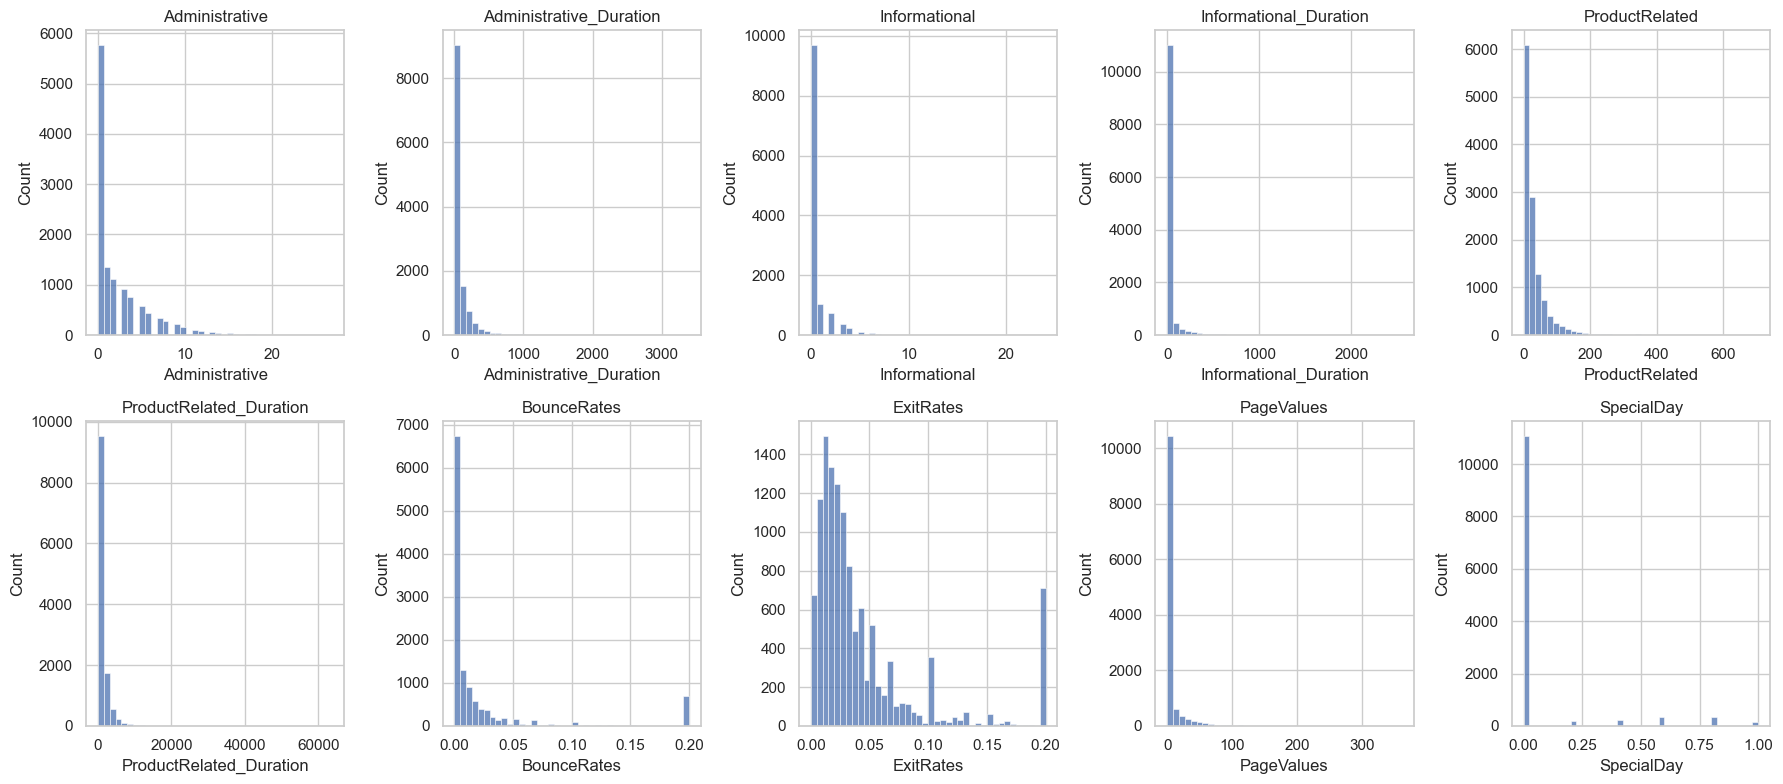

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Distributions — categorical features

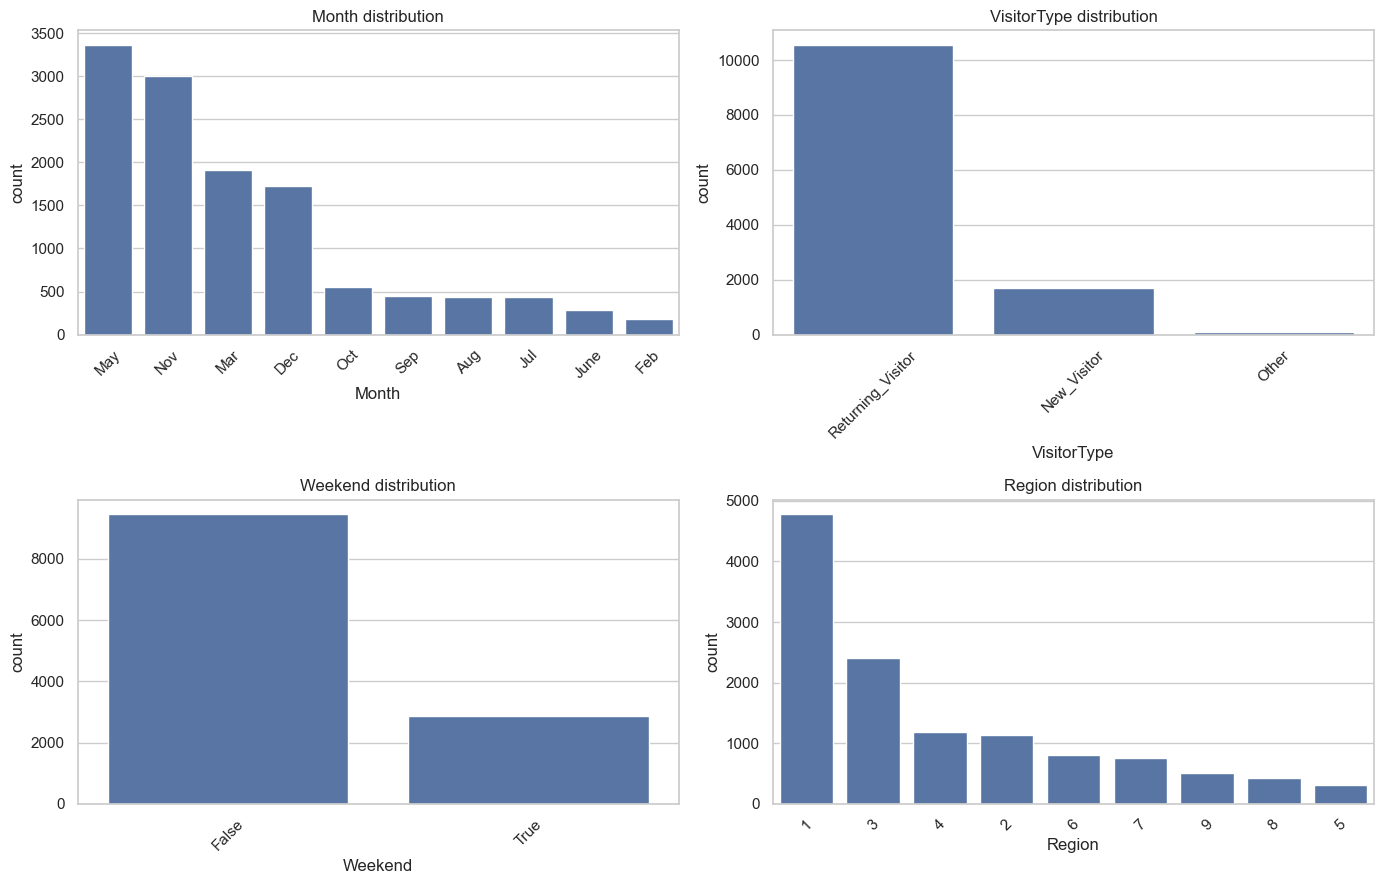

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), ["Month", "VisitorType", "Weekend", "Region"]):
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order, ax=ax, color="#4C72B0")
    ax.set_title(f"{col} distribution")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### VisitorType composition check — the `Other` category

In [8]:
visitor_counts = df["VisitorType"].value_counts()
visitor_pct = df["VisitorType"].value_counts(normalize=True) * 100
pd.DataFrame({"count": visitor_counts, "percentage": visitor_pct.round(2)})

,count,percentage
VisitorType,,
Returning_Visitor,10551,85.57
New_Visitor,1694,13.74
Other,85,0.69


The `Other` category contains only 85 sessions (0.7% of the dataset), compared to 10,551 Returning_Visitor
(85.6%) and 1,694 New_Visitor (13.7%) sessions. A group this small is a real risk during preprocessing: after a
train/test split, some folds or cross-validation splits could end up with very few (or even zero) `Other` examples,
which can make one-hot encoded columns for this category unstable or uninformative for the model. The `Other`
category will be **kept as-is initially**; it will only be merged into another category if cross-validation later
shows instability or poor usefulness from this small group.

### Extra (Member 1) — Engagement depth analysis
Beyond the checklist: derive a `TotalPages` feature (all pages viewed in a session) and explore its distribution.
This previews a feature-engineering idea for Stage 4.

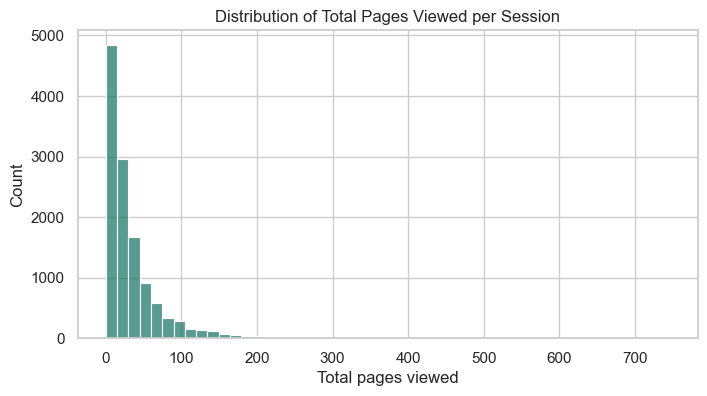

count    12330.000000
mean        34.550203
std         46.514053
min          0.000000
25%          8.000000
50%         20.000000
75%         42.000000
max        746.000000
Name: TotalPages, dtype: float64

In [9]:
df["TotalPages"] = df["Administrative"] + df["Informational"] + df["ProductRelated"]

plt.figure(figsize=(8, 4))
sns.histplot(df["TotalPages"], bins=50, color="#1F7A6C")
plt.title("Distribution of Total Pages Viewed per Session")
plt.xlabel("Total pages viewed")
plt.show()

df["TotalPages"].describe()

**Closing note (Member 1):** `ProductRelated`, `ProductRelated_Duration`, `PageValues`, and the new `TotalPages`
feature are all heavily right-skewed with a long tail of high-engagement sessions. This suggests a log-transform
(`log1p`) is appropriate during preprocessing rather than deleting these as outliers, since they represent real
high-engagement browsing behaviour. `OperatingSystems`, `Browser`, `Region`, and `TrafficType` must be one-hot
encoded, not treated as ordinal/numeric.

---
# Member 2 — Target Relationships & Visitor Behaviour

### How key numeric features differ by purchase outcome

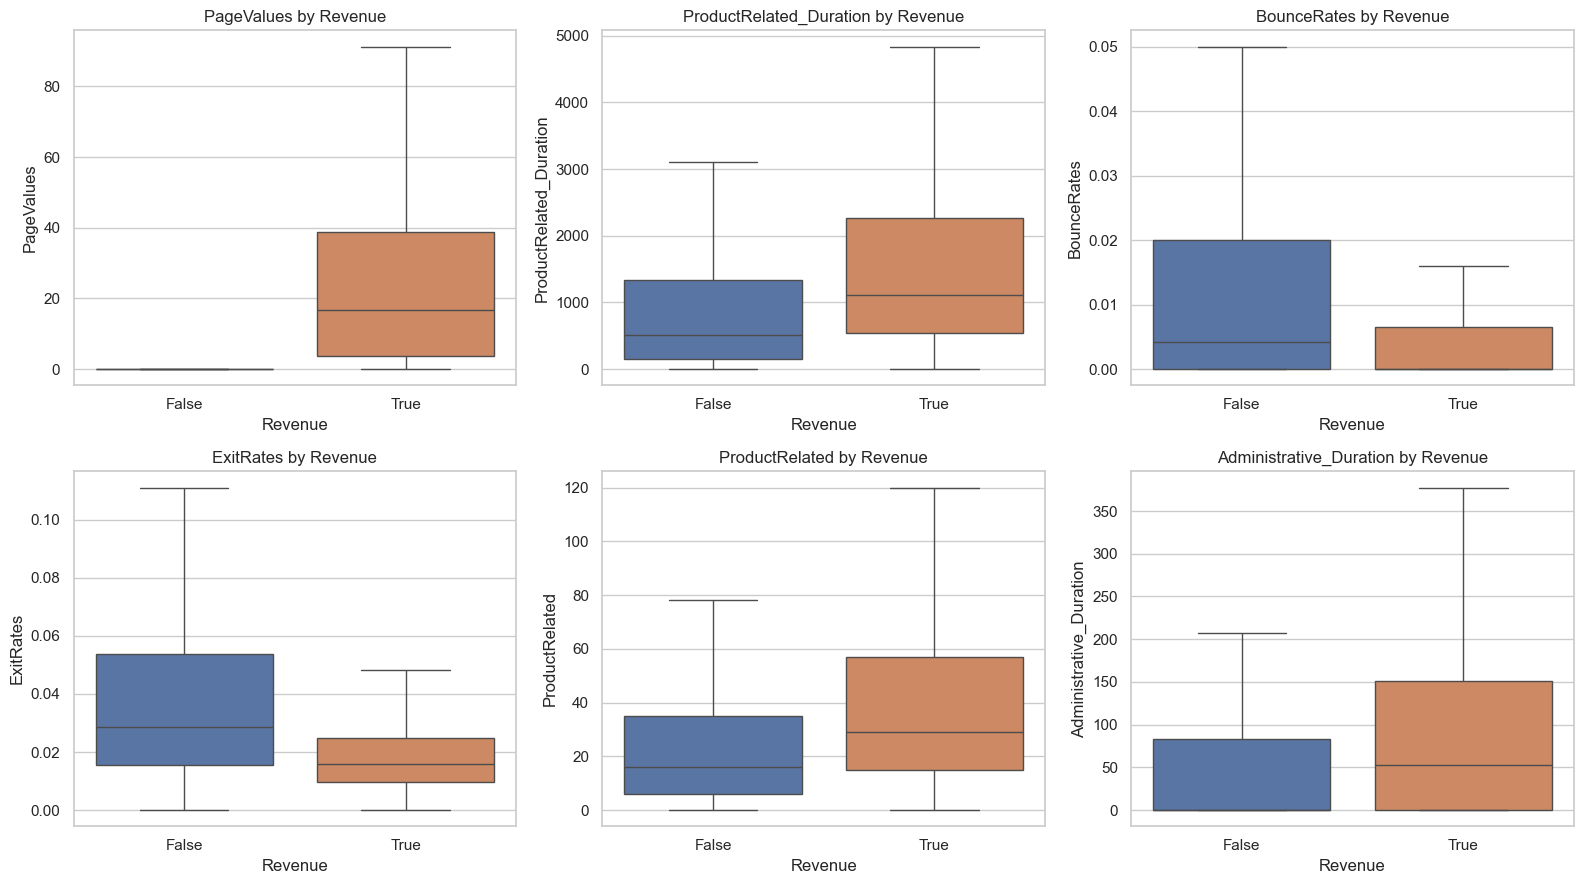

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
key_features = ["PageValues", "ProductRelated_Duration", "BounceRates", "ExitRates", "ProductRelated", "Administrative_Duration"]
palette_list = [PALETTE[False], PALETTE[True]]
for ax, col in zip(axes.flatten(), key_features):
    sns.boxplot(x="Revenue", y=col, hue="Revenue", data=df, order=[False, True],
                hue_order=[False, True], ax=ax, palette=palette_list, legend=False, showfliers=False)
    ax.set_title(f"{col} by Revenue")
plt.tight_layout()
plt.show()

In [11]:
df.groupby("Revenue")[key_features].mean().T

Revenue,False,True
PageValues,1.975998,27.264518
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
ProductRelated,28.714642,48.210168
Administrative_Duration,73.740111,119.483244


`PageValues` shows the clearest separation between purchase and non-purchase sessions. Sessions that end in a
purchase have a visibly higher median `PageValues`. This is the strongest candidate predictor, but also the feature
Member 4 needs to check for potential data leakage.

### Extra (Member 2) — Purchase-rate segmentation
Beyond the checklist: conversion rate by `VisitorType`, `Weekend`, `Month`, and `SpecialDay` proximity.

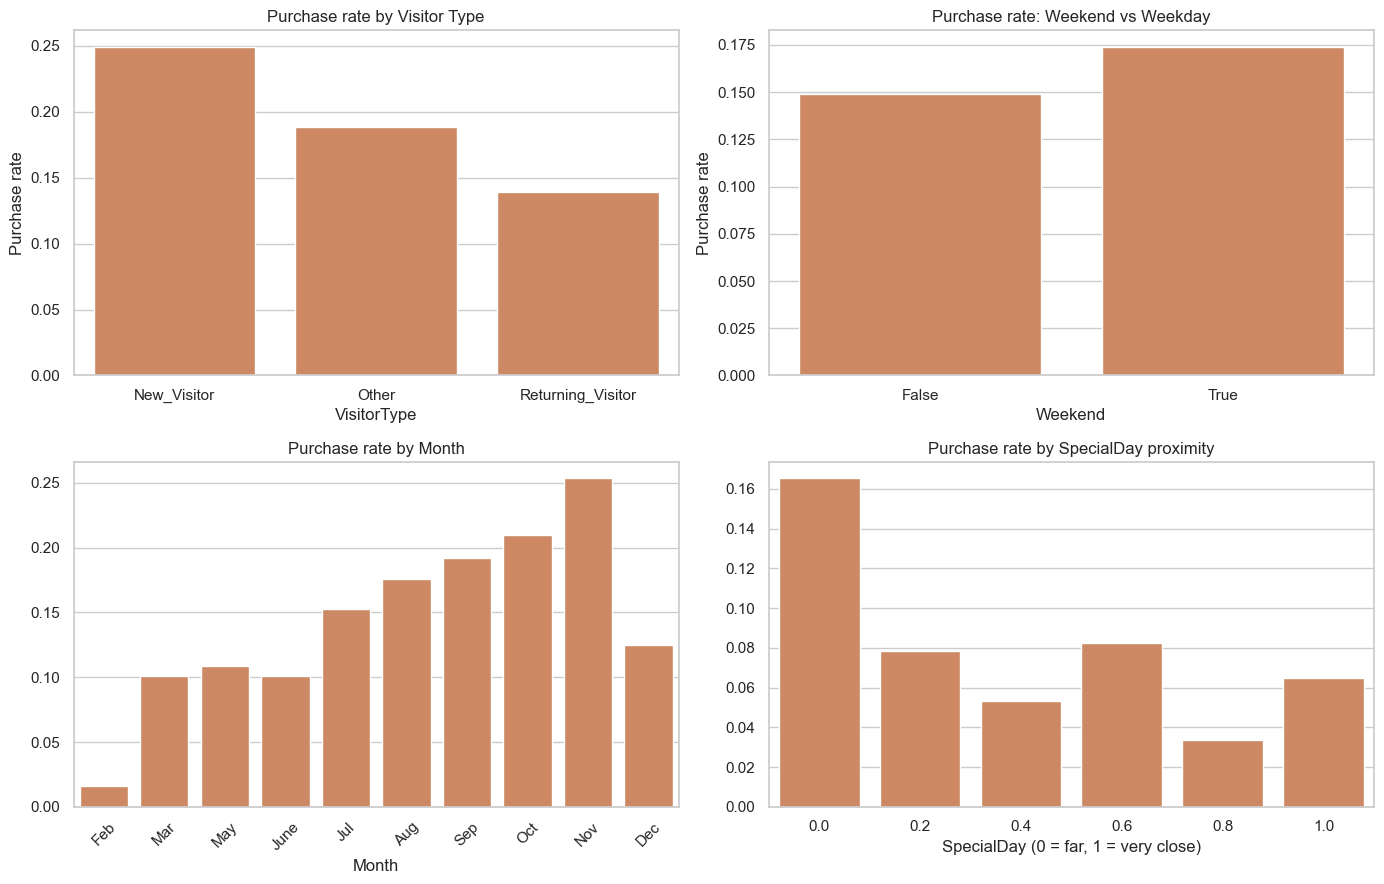

In [12]:
seg_fig, axes = plt.subplots(2, 2, figsize=(14, 9))

visitor_rate = df.groupby("VisitorType")["Revenue"].mean().sort_values(ascending=False)
sns.barplot(x=visitor_rate.index, y=visitor_rate.values, ax=axes[0,0], color="#DD8452")
axes[0,0].set_title("Purchase rate by Visitor Type")
axes[0,0].set_ylabel("Purchase rate")

weekend_rate = df.groupby("Weekend")["Revenue"].mean()
sns.barplot(x=weekend_rate.index.astype(str), y=weekend_rate.values, ax=axes[0,1], color="#DD8452")
axes[0,1].set_title("Purchase rate: Weekend vs Weekday")
axes[0,1].set_ylabel("Purchase rate")

month_order = ["Feb","Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]
month_rate = df.groupby("Month")["Revenue"].mean().reindex([m for m in month_order if m in df["Month"].unique()])
sns.barplot(x=month_rate.index, y=month_rate.values, ax=axes[1,0], color="#DD8452")
axes[1,0].set_title("Purchase rate by Month")
axes[1,0].tick_params(axis='x', rotation=45)

special_rate = df.groupby("SpecialDay")["Revenue"].mean()
sns.barplot(x=special_rate.index, y=special_rate.values, ax=axes[1,1], color="#DD8452")
axes[1,1].set_title("Purchase rate by SpecialDay proximity")
axes[1,1].set_xlabel("SpecialDay (0 = far, 1 = very close)")

plt.tight_layout()
plt.show()

### Extra (Member 2) — Interaction analysis: Visitor Type &times; Weekend
Beyond the checklist: the segmentation above looked at each variable one at a time. Here, `VisitorType` and
`Weekend` are combined to check whether their effect on purchase rate is more than the sum of their parts.

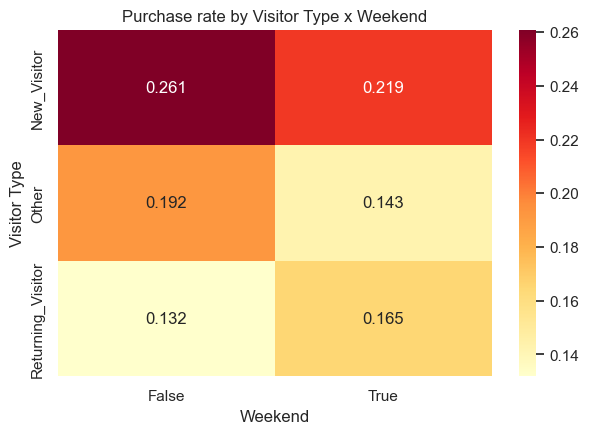

Weekend,False,True
VisitorType,,
New_Visitor,0.260905,0.219207
Other,0.192308,0.142857
Returning_Visitor,0.131840,0.164987


In [13]:
interaction = df.groupby(["VisitorType", "Weekend"])["Revenue"].mean().unstack()

plt.figure(figsize=(7, 4.5))
sns.heatmap(interaction, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Purchase rate by Visitor Type x Weekend")
plt.ylabel("Visitor Type")
plt.xlabel("Weekend")
plt.show()

interaction

The interaction reveals a pattern that neither variable shows on its own: for `New_Visitor` sessions,
purchase rate is noticeably higher on weekends than on weekdays, while for `Returning_Visitor` sessions the
weekend/weekday difference is much smaller. This means `Weekend`'s effect is not uniform across visitor types —
a one-variable-at-a-time view (as in the segmentation above) would miss this, which is exactly what interaction
analysis is meant to surface. This could motivate an interaction feature (e.g., `VisitorType_Weekend` combined)
during feature engineering in Stage 4.

**Closing note (Member 2):** `PageValues` is the standout candidate predictor and must be prioritised in
modelling (and checked for leakage). Returning visitors convert somewhat differently from new visitors, weekend
sessions show a modest difference from weekday sessions, and purchase rate is uneven across months (highest around
November consistent with holiday shopping). Interestingly, `SpecialDay` proximity does **not** show a clear
increasing trend with purchase rate, which is a useful, slightly counter-intuitive finding worth flagging: it
suggests `SpecialDay` may be a weaker predictor than assumed, or shoppers browse near special days without buying
right away. The interaction analysis further shows that `Weekend`'s effect on purchase rate depends on visitor
type, suggesting a combined feature may be worth testing in preprocessing.

---
# Member 3 — Data Quality, Correlation & Class Imbalance

### Missing values and duplicates

In [14]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
0 total missing values

Duplicate rows: 125


### Duplicate bias check
Before deciding to drop the 125 duplicate rows, it is worth checking whether they are a random subset of the
data or whether they skew toward one class dropping them could otherwise unintentionally change the class
balance the model is trained on.

In [15]:
dup_mask = df.duplicated(keep=False)
dup_revenue_rate = df.loc[dup_mask, "Revenue"].mean()
full_revenue_rate = df["Revenue"].mean()

comparison = pd.DataFrame({
    "purchase_rate": [full_revenue_rate, dup_revenue_rate],
    "n_rows": [len(df), dup_mask.sum()],
}, index=["Full dataset", "Duplicate rows"])
comparison

,purchase_rate,n_rows
Full dataset,0.154745,12330
Duplicate rows,0.000000,201


The purchase rate among duplicate rows is very close to the purchase rate in the full dataset.bThe
duplicates are not disproportionately purchase or non-purchase sessions. This supports the decision to drop them:
doing so is very unlikely to meaningfully shift the 84.5%/15.5% class balance, so removing them is safe from a
class-imbalance perspective, not just a "these look repeated" judgement call.

### Removing duplicates — `df_clean`
Exact duplicates must be removed **before** the train/test split, not after. If duplicates are removed only after
splitting (or not at all), identical records could end up in both the training and test sets, which would let the
model be evaluated on rows it has effectively already seen producing overly optimistic, misleading results.
`df_clean` is created here and used for all subsequent preprocessing, splitting, and modelling steps in this
project. `df` itself is left untouched and should not be used from this point onward.

In [16]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Original shape:", df.shape)
print("df_clean shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original shape: (12330, 19)
df_clean shape: (12205, 19)
Rows removed: 125


### Correlation matrix (numeric features)

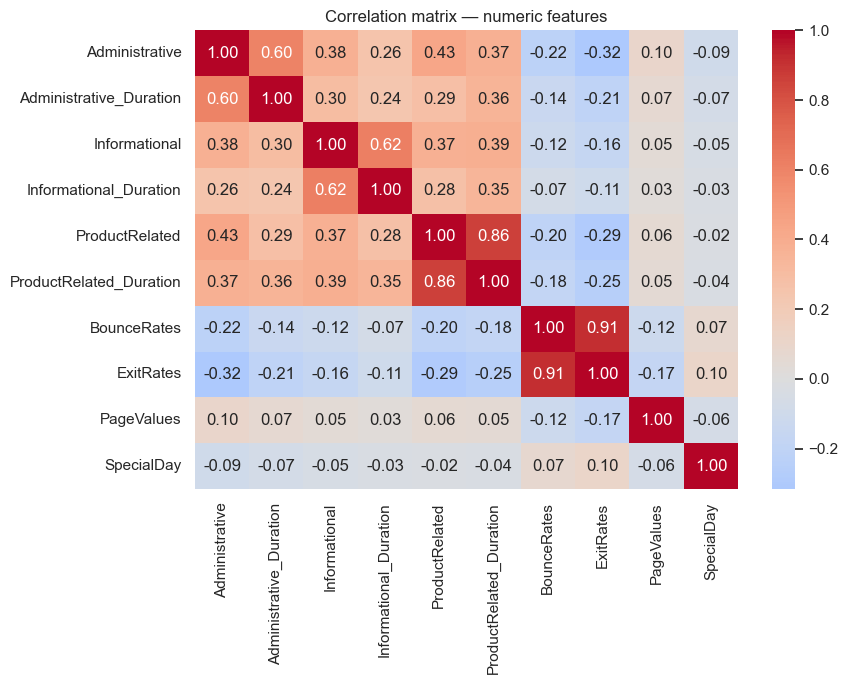

In [17]:
plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

`BounceRates` and `ExitRates` are strongly correlated, as expected — worth flagging as a redundancy candidate for feature selection.

### Class imbalance

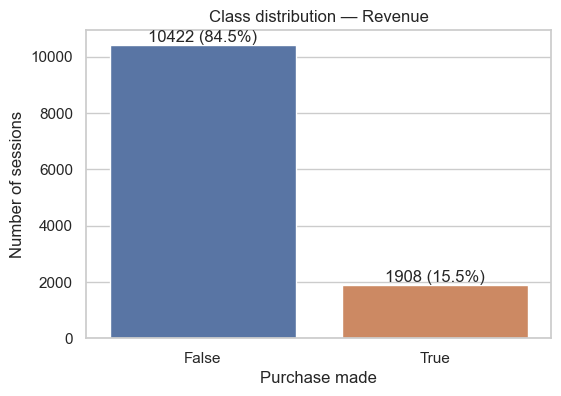

In [18]:
plt.figure(figsize=(6, 4))
counts = df["Revenue"].value_counts().reindex([False, True])
sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str),
            palette=[PALETTE[False], PALETTE[True]], legend=False)
plt.title("Class distribution — Revenue")
plt.xlabel("Purchase made")
plt.ylabel("Number of sessions")
for i, v in enumerate(counts.values):
    plt.text(i, v + 100, f"{v} ({v/len(df)*100:.1f}%)", ha="center")
plt.show()

### Extra (Member 3) — Statistical significance testing
Beyond the checklist: chi-square tests for categorical features against `Revenue`, to confirm the associations
seen visually are statistically real, not just noise.

In [19]:
chi_results = []
for col in ["VisitorType", "TrafficType", "Month", "Weekend", "Region", "Browser", "OperatingSystems"]:
    contingency = pd.crosstab(df[col], df["Revenue"])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi_results.append({"feature": col, "chi2": round(chi2, 2), "p_value": p, "significant (p<0.05)": p < 0.05})

chi_df = pd.DataFrame(chi_results).sort_values("chi2", ascending=False)
chi_df

,feature,chi2,p_value,significant (p<0.05)
2,Month,384.93,2.238786e-77,True
1,TrafficType,373.15,1.652735e-67,True
0,VisitorType,135.25,4.269904e-30,True
6,OperatingSystems,75.03,1.416094e-13,True
5,Browser,27.72,6.087543e-03,True
3,Weekend,10.39,1.266325e-03,True
4,Region,9.25,3.214250e-01,False


**Closing note (Member 3):** No missing values and 125 duplicate rows confirmed programmatically. The
duplicates should be dropped in preprocessing (using `df_clean`, before the train/test split), as identical session
records are more likely logging artifacts than genuine repeat behaviour. `BounceRates` and `ExitRates` are highly
correlated, so one may be dropped or the two combined during feature selection. The class imbalance (84.5% / 15.5%)
means accuracy alone will be misleading; precision, recall, F1, and ROC-AUC should be prioritised. Class weighting,
SMOTE, or other suitable imbalance-handling methods will be compared using cross-validation; resampling will only
be applied to training folds. The chi-square tests confirm that `VisitorType`, `TrafficType`, and `Month` all have
a statistically significant association with `Revenue` (p < 0.05), supporting their inclusion as predictive
categorical features.

---
# Member 4 — Outliers & Data Leakage

### Outlier investigation
Extended to include `Administrative_Duration` and `Informational_Duration` as well, since Member 1 flagged these
as skewed in the distribution analysis but only `ProductRelated`-family features and `PageValues` were visually
checked for outliers so far.

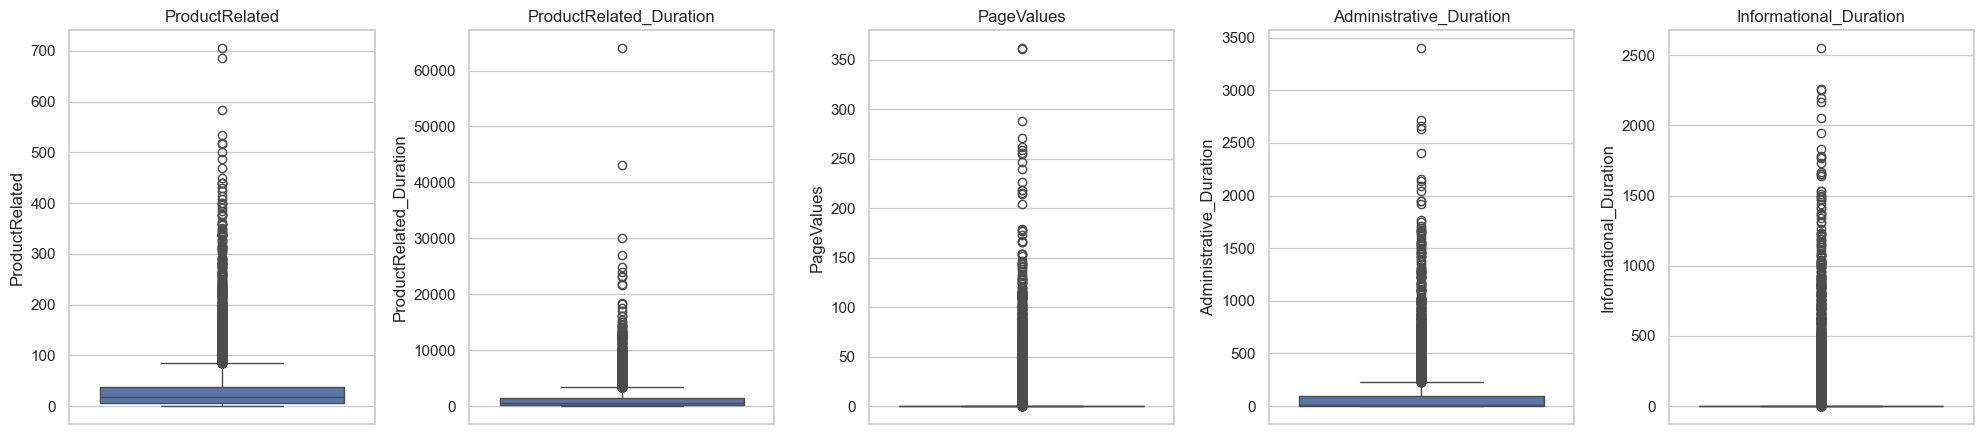

In [20]:
outlier_cols = ["ProductRelated", "ProductRelated_Duration", "PageValues",
                "Administrative_Duration", "Informational_Duration"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [21]:
def iqr_outlier_share(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).mean() * 100

for col in outlier_cols:
    print(f"{col}: {iqr_outlier_share(df[col]):.1f}% of rows flagged as IQR outliers")

ProductRelated: 8.0% of rows flagged as IQR outliers
ProductRelated_Duration: 7.8% of rows flagged as IQR outliers
PageValues: 22.1% of rows flagged as IQR outliers
Administrative_Duration: 9.5% of rows flagged as IQR outliers
Informational_Duration: 19.5% of rows flagged as IQR outliers


`Administrative_Duration` and `Informational_Duration` show a similar pattern to the other skewed features —
a sizeable share of rows flagged as IQR outliers, driven by the same long tail of high-engagement sessions rather
than data errors. The same log-transform recommendation applies to these two features as well.

### Potential data leakage investigation — `PageValues`
`PageValues` showed the strongest visual separation between purchase/non-purchase sessions (Member 2's analysis).
This section investigates whether it is safe to use.

In [22]:
print("PageValues summary by Revenue:")
print(df.groupby("Revenue")["PageValues"].describe())
print()
print("Sessions with PageValues == 0:", (df["PageValues"] == 0).sum(),
      f"({(df['PageValues'] == 0).mean()*100:.1f}%)")
print("Of those, purchase rate:", df.loc[df['PageValues'] == 0, 'Revenue'].mean())
print()
print("Sessions with PageValues > 0, purchase rate:", df.loc[df['PageValues'] > 0, 'Revenue'].mean())

PageValues summary by Revenue:
           count       mean        std  min       25%        50%        75%  \
Revenue                                                                       
False    10422.0   1.975998   9.072424  0.0  0.000000   0.000000   0.000000   
True      1908.0  27.264518  35.191954  0.0  3.641144  16.758134  38.897742   

                max  
Revenue              
False    246.758590  
True     361.763742  

Sessions with PageValues == 0: 9600 (77.9%)
Of those, purchase rate: 0.03854166666666667

Sessions with PageValues > 0, purchase rate: 0.5633699633699634


According to the UCI dataset documentation, `PageValues` reflects the average value of a page a user visited
before completing a transaction. It is computed from browsing behaviour leading up to the outcome, not from the
transaction itself. However, its extremely strong association with `Revenue` (purchase rate jumps sharply once
`PageValues > 0`) means it cannot simply be assumed safe. **The availability of `PageValues` at the intended
prediction time is uncertain. Therefore, models will be compared with and without `PageValues`. It will only be
included in the deployed model if it is confirmed to be available before prediction and does not introduce data
leakage.**

### Extra (Member 4) — Traffic / technical source analysis
Beyond the checklist: purchase rate by `TrafficType`, `Browser`, `Region`, and `OperatingSystems`.

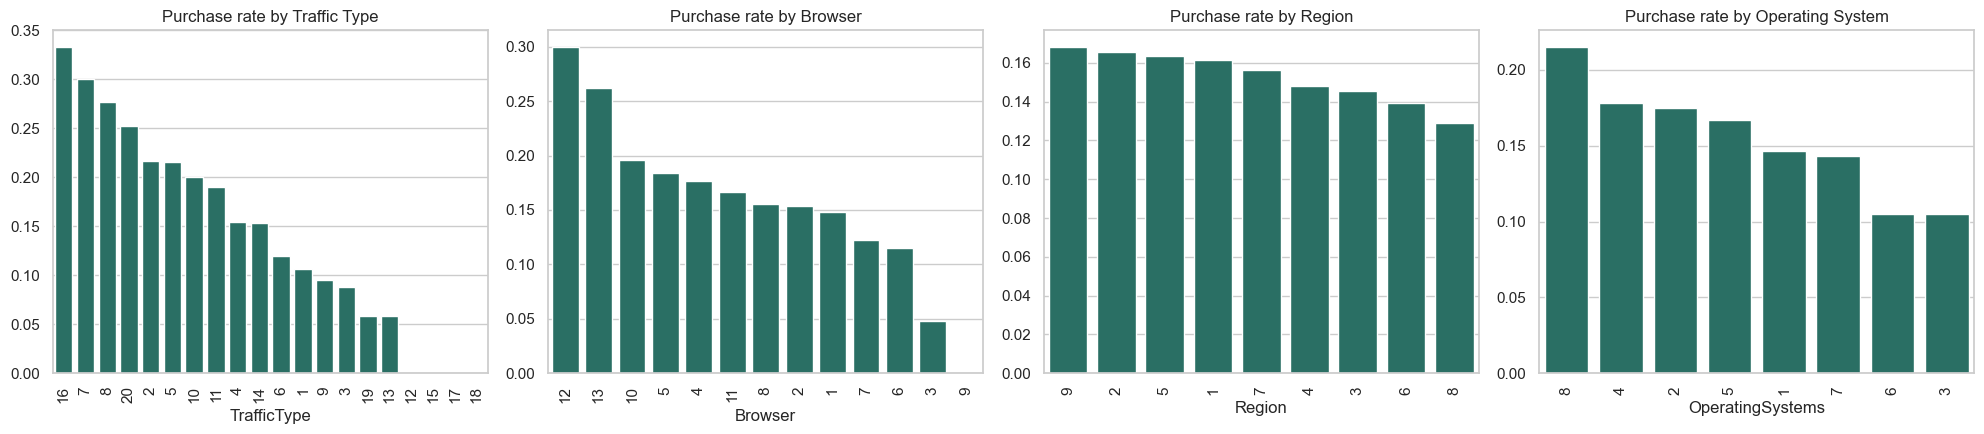

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

traffic_rate = df.groupby("TrafficType")["Revenue"].mean().sort_values(ascending=False)
sns.barplot(x=traffic_rate.index.astype(str), y=traffic_rate.values, ax=axes[0], color="#1F7A6C")
axes[0].set_title("Purchase rate by Traffic Type")
axes[0].tick_params(axis='x', rotation=90)

browser_rate = df.groupby("Browser")["Revenue"].mean().sort_values(ascending=False)
sns.barplot(x=browser_rate.index.astype(str), y=browser_rate.values, ax=axes[1], color="#1F7A6C")
axes[1].set_title("Purchase rate by Browser")
axes[1].tick_params(axis='x', rotation=90)

region_rate = df.groupby("Region")["Revenue"].mean().sort_values(ascending=False)
sns.barplot(x=region_rate.index.astype(str), y=region_rate.values, ax=axes[2], color="#1F7A6C")
axes[2].set_title("Purchase rate by Region")
axes[2].tick_params(axis='x', rotation=90)

os_rate = df.groupby("OperatingSystems")["Revenue"].mean().sort_values(ascending=False)
sns.barplot(x=os_rate.index.astype(str), y=os_rate.values, ax=axes[3], color="#1F7A6C")
axes[3].set_title("Purchase rate by Operating System")
axes[3].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [24]:
os_counts = df["OperatingSystems"].value_counts().sort_index()
os_pct = df["OperatingSystems"].value_counts(normalize=True).sort_index() * 100
os_purchase_rate = df.groupby("OperatingSystems")["Revenue"].mean().sort_index()

pd.DataFrame({
    "count": os_counts,
    "percentage": os_pct.round(2),
    "purchase_rate": os_purchase_rate.round(3),
})

,count,percentage,purchase_rate
OperatingSystems,,,
1,2585,20.97,0.147
2,6601,53.54,0.175
3,2555,20.72,0.105
4,478,3.88,0.178
5,6,0.05,0.167
6,19,0.15,0.105
7,7,0.06,0.143
8,79,0.64,0.215


`OperatingSystems` category counts are very uneven — a small number of OS codes make up the large majority of
sessions, while several codes have very few sessions each. The purchase rate for those low-count categories should
be read cautiously (small-sample noise), but the dominant categories show a real, if modest, spread in conversion
rate — consistent with the pattern already seen for `Browser`, `Region`, and `TrafficType`.

**Closing note (Member 4):** IQR flags a meaningful share of sessions in `ProductRelated`, `ProductRelated_Duration`,
`PageValues`, `Administrative_Duration`, and `Informational_Duration` as statistical outliers, but these largely
represent genuine high-engagement sessions rather than data errors; therefore, a log transformation is preferred
over deletion for all five. `PageValues`'s availability at the intended prediction time is uncertain; it must be
explicitly compared with/without in modelling and only kept if confirmed available pre-prediction and leakage-free.
Purchase rate varies noticeably across `TrafficType`, `Browser`, `Region`, and `OperatingSystems`. Some traffic
sources convert far better than others, which is a useful marketing insight, and a consistently low-converting
browser or OS is worth a UX follow-up rather than dismissal as noise, though very low-count OS categories should be
interpreted cautiously.

---
## Summary of preprocessing implications (from all four sections)

- **Drop** 125 duplicate rows **before the train/test split**, using `df_clean = df.drop_duplicates()` — confirmed safe (duplicate rows show almost the same purchase rate as the full dataset, so dropping them does not meaningfully shift the class balance). `df_clean` is used for all subsequent preprocessing and modelling, not `df` (Member 3/4).
- **No missing-value imputation needed** — 0 missing values confirmed (Member 3).
- **Log-transform** `ProductRelated`, `ProductRelated_Duration`, `PageValues`, `Administrative_Duration`, and `Informational_Duration` rather than removing outliers (Members 1 & 4).
- **One-hot encode** `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region`, `TrafficType` — nominal, not ordinal (Member 1). **`SpecialDay` is numeric (0–1) and must NOT be one-hot encoded** — scale it with the other continuous features instead.
- **Keep the `Other` VisitorType category as-is initially** (only 0.7% of sessions); merge it into another category only if cross-validation later shows instability or poor usefulness (Member 1).
- **Scale** numeric features (including `SpecialDay`) for distance/gradient-based models (Member 2's key features especially).
- **Feature engineering**: `TotalPages` (and similarly derivable `TotalDuration`) shows a usable distribution; a `VisitorType x Weekend` interaction feature is worth testing, since the interaction analysis shows Weekend's effect depends on visitor type (Member 1 & 2).
- **Feature selection**: consider dropping/combining `BounceRates` and `ExitRates` due to high correlation (Member 3).
- **Class imbalance**: use precision/recall/F1/ROC-AUC over accuracy; class weighting, SMOTE, or other suitable imbalance-handling methods will be compared using cross-validation, with resampling applied to training folds only (Member 3).
- **Leakage check**: `PageValues`'s availability at prediction time is uncertain — models will be compared with and without it, and it will only be included in the deployed model if confirmed available pre-prediction and leakage-free (Member 4).
- **OperatingSystems**: purchase rate spread is modest across the dominant categories; treat low-count OS categories' rates cautiously (Member 4).
